# Hand-Written Digit Classification

In this assignment you will implement multi-class classification for
hand-written digits and run a few experiments. The file ``digits-py.mat``
is a data file containing the data set, which is split into a
training set with 4000 examples, and a test set with 1000 examples.

You can import the data as a Python dictionary like this:
``` .python
data = scipy.io.loadmat('digits-py.mat')
```

The code in the cell below first does some setup and then imports the data
into the following variables for training and test data:

* ``X_train`` - 2d array shape 4000 x 400
* ``y_train`` - 1d array shape 4000
* ``X_test`` - 2d array shape 1000 x 400
* ``y_test`` - 1d array shape 1000

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Load train and test data
import scipy.io
data = scipy.io.loadmat('digits-py.mat')
X_train = data['X_train']
y_train = data['y_train'].ravel()
X_test  = data['X_test']
y_test  = data['y_test'].ravel()

## Code to visualize the data

Once you have loaded the data, it is helpful to understand how it represents images. Each row of ``X_train`` and ``X_test`` represents a 20 x 20 image as a vector of length 400 containing the pixel intensity values. To see the original image, you can reshape one row of the train or test data into a 20 x 20 matrix and then visualize it using the matlplotlib ``imshow`` command. 

Here is the code using ``np.reshape`` and ``plt.imshow`` to display the 100th training example as an image. (we have used ``cmap='gray'`` in ``plt.imshow`` to view as a grayscale image.)

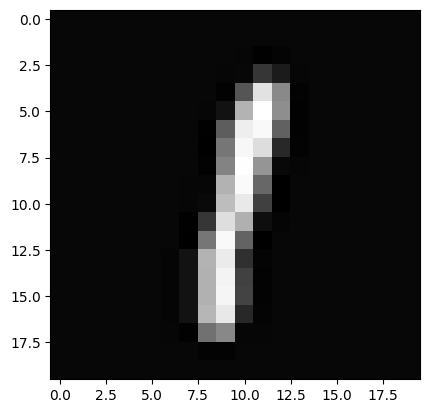

In [2]:

# getting the 100th training example
ex = X_train[99,:]
# converting it to a 20X20 image
image = np.reshape(ex,(20,20))
# displaying the image
plt.imshow(image,cmap = 'gray')

## Explore the data

There is a utility function ``display_data`` in ``hw4b.py`` for you to further visualize the data by showing a mosaic of many digits at the same time. For example, you can display the first 25 training examples like this:
``` .python
display_data( X_train[:,25, :] )
```

Go ahead and do this to visualize the first 25 training examples. Then print the corresponding labels to see if they match.

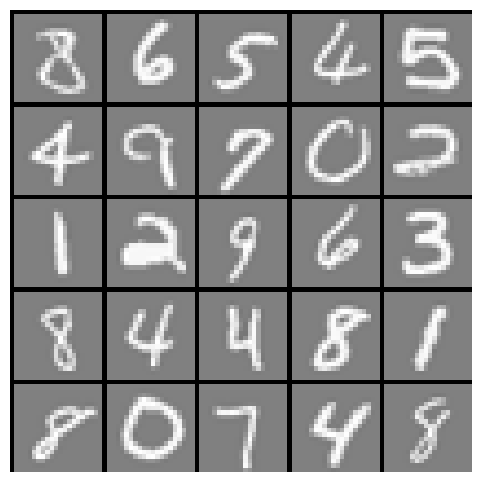

[8 6 5 4 5 4 9 7 0 2 1 2 9 6 3 8 4 4 8 1 8 0 7 4 8]


In [ ]:
from hw4b import display_data

"""
NOTE: I modified display_data function in hw4b.py to replace np.int with Python's int due to removal in NumPy 2.0+ (I'm using 2.2.5).
The changes are minimal, replacing np.int in two lines (im_width and im_height calculations). Additionally, I changed np.lib.pad to np.pad at line 149.
This was necessary in order to visualize the 25 images.
"""
# TODO: Write code here
display_data( X_train[0:25, :] )

# checking the first 25 values to ensure they match the images (i.e., printing the true values of y)
print(y_train[0:25])


## Alert: notation change!

Please read this carefully to understand the notation used in the assignment. We will use logistic regression to solve multi-class classification. For three reasons (ease of displaying parameters as images, compatibility with scikit learn, previewing notation for SVMs and neural networks), we will change the notation as described here.

### Old notation
Previously we defined our model as
$$
h_{\boldsymbol{\theta}}(\mathbf{x}) = \text{logistic}(\theta_0 + \theta_1 x_1 + \ldots + \theta_n x_n)  = \text{logistic}(\boldsymbol{\theta}^T \mathbf{x})
$$
where 

* $\mathbf{x} = \begin{bmatrix}1, x_1, \ldots, x_n\end{bmatrix}$ was a feature vector with a 1 added in the first position
* $\boldsymbol{\theta} = \begin{bmatrix}\theta_0, \theta_1, \ldots, \theta_n\end{bmatrix}$ was a parameter vector with the intercept parameter $\theta_0$ in the first position

### New notation

We will now define our model as
$$
h_{\mathbf{w}}(\mathbf{x}) = \text{logistic}(b + w_1 x_1 + \ldots + w_n x_n)  = \text{logistic}(\mathbf{w}^T \mathbf{x} + b)
$$
where 

* $\mathbf{x} \in \mathbb{R}^n$ is the **original feature vector** with no 1 added
* $\mathbf{w} \in \mathbb{R}^n$ is a **weight vector** (equivalent to $\theta_1, \ldots, \theta_n$ in the old notation)
* $b$ is a scalar **intercept parameter** (equivalent to $\theta_0$ in our old notation)

## One-vs-All Logistic Regression

Now you will implement one vs. all multi-class classification using logistic regression. Recall the method presented in class. Suppose we are solving a $K$ class problem given training examples in the data matrix $X \in \mathbb{R}^{m \times n}$ and label vector
$\mathbf{y} \in \mathbb{R}^{m}$ (the entries of $\mathbf{y}$ can be from $1$ to
$K$). 

**For each class $c = 1,\ldots,K$**, fit a logistic regression model
to distinguish class $c$ from the others using the
labels

$$
y_c^{(i)} = 
\begin{cases}
1 & \text{if } y^{(i)} = c \\
0 & \text{otherwise}.
\end{cases}
$$

This training
procedure  will result in a weight vector $\mathbf{w}_c$ and an intercept parameter $b_c$
that can be used to predict the probability that a new example $\mathbf{x}$ belongs to class $c$:

$$
\text{logistic}(\mathbf{w}_c^T \mathbf{x} + b_c) = \text{probability that $\mathbf{x}$
  belongs to class $c$}.
$$

The overall training procedure will yield one weight vector for each
class. To make the final prediction for a new example, select the
class with highest predicted probability:

$$
\text{predicted class} = \text{the value of $c$ that maximizes } \text{logistic}(\mathbf{w}_c^T \mathbf{x} + b_c).
$$

### Training ###

Open the file ``hw4b.py`` and complete the function ``train_one_vs_all`` 
to train binary classifiers using the procedure outlined 
above. 

Follow the instructions in the file for more details. Once you are done, test your implementation by running the code below to train the model and display the weight 
vectors as images. You should see images that are recognizable as the digits 0 through 9 (some are only vague impressions of the digit).

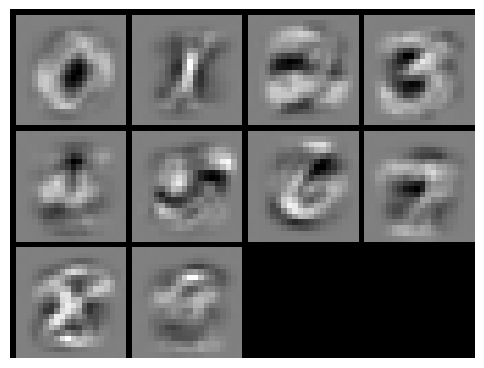

In [6]:
from hw4b import train_one_vs_all

lambda_val = 100
weight_vectors, intercepts = train_one_vs_all(X_train, y_train, 10, lambda_val)
display_data(weight_vectors.T) # display weight vectors as images

### Predictions

Now complete the function ``predict_one_vs_all`` in ``hw4b.py`` and run the code below to make predictions on the train and test sets. You should see accuracy around 88% on the test set.

In [7]:
from hw4b import predict_one_vs_all

pred_train = predict_one_vs_all(X_train, weight_vectors, intercepts)
pred_test  = predict_one_vs_all(X_test,  weight_vectors, intercepts)

print("Training Set Accuracy: %f" % (np.mean(pred_train == y_train) * 100))
print("    Test Set Accuracy: %f" % (np.mean( pred_test == y_test) * 100))

Training Set Accuracy: 89.225000
    Test Set Accuracy: 88.300000


## Regularization Experiment

Now you will experiment with different values of the regularization 
parameter $\lambda$ to control overfitting. We will measure the training 
and test accuracy for values of $\lambda$ that are powers of 10 ranging from 
$10^{-3}$ to $10^5$.

* Display the weight vectors for each value of $\lambda$ as an image using the ``display_data`` function
* Save the training and test accuracy for each value of $\lambda$
* Plot training and test accuracy versus lambda (in one plot). 

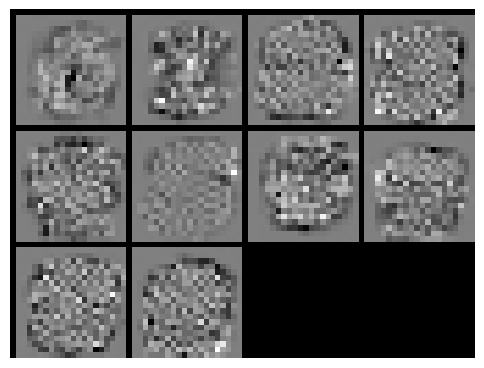

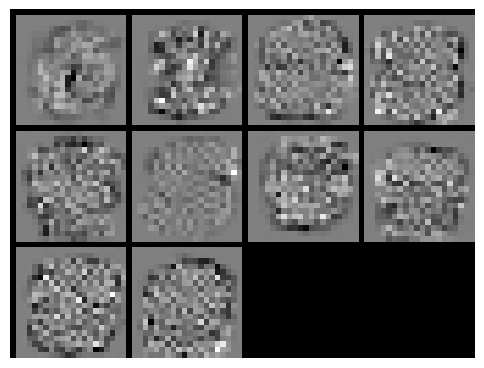

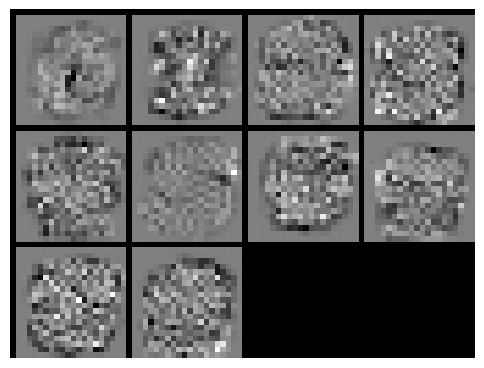

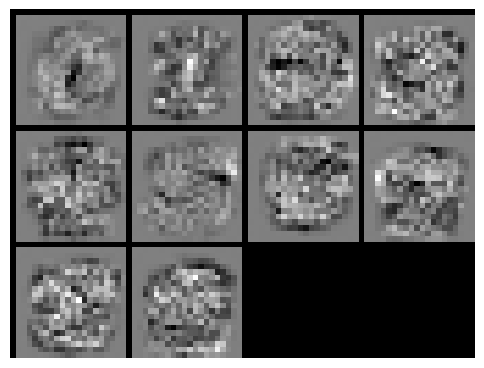

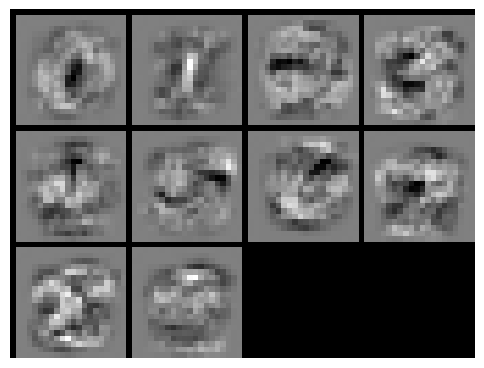

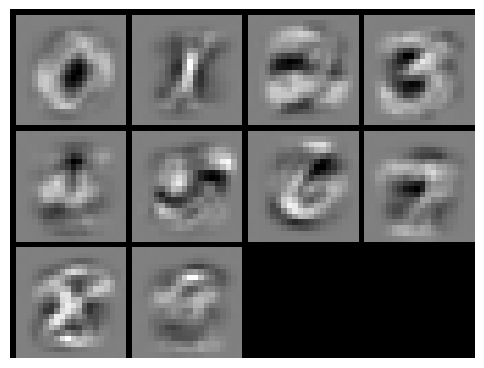

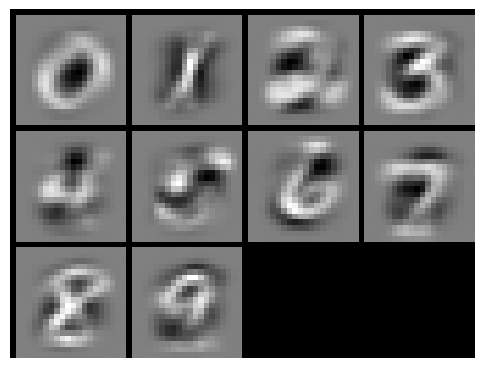

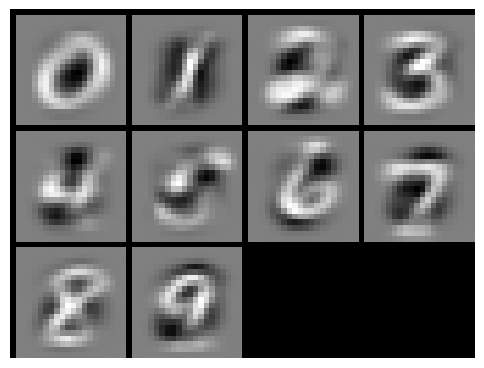

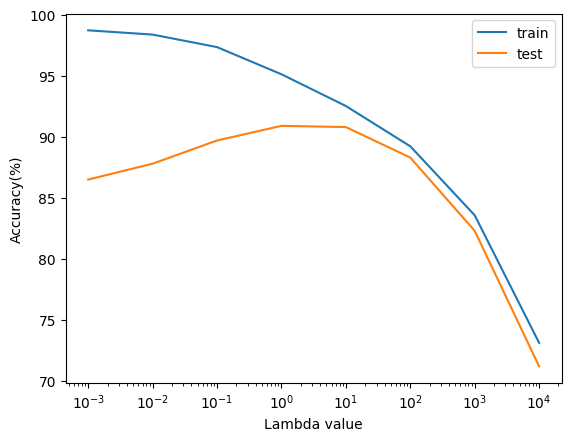

In [8]:
lambda_vals = 10**np.arange(-3., 5.)
num_classes = 10



# the list for the accuracies in the training data
listtrain =[]
# the list for the accuracies in the test data
listtest = []

for i in range(len(lambda_vals)):
    # getting weight vectors and the intecepts using one vs. all approach
    weight_vectors, intercepts = train_one_vs_all(X_train, y_train, num_classes, lambda_vals[i])
    display_data(weight_vectors.T)
    # predicitng the model for the training set
    pred_train = predict_one_vs_all(X_train, weight_vectors, intercepts)
    # predicting the model for the test set
    pred_test  = predict_one_vs_all(X_test,  weight_vectors, intercepts)
    
    # adding the accuracies of the training set to the list
    listtrain.append((np.mean(pred_train == y_train) * 100))
    # adding the accuracies of the training set to the list
    listtest.append((np.mean(pred_test == y_test) * 100))

# In your final plot, use these commands to provide a legend and set 
# the horizontal axis to have a logarithmic scale so the value of lambda
# appear evenly spaced.

# plotting the accuracies vs. lambada values
plt.plot(lambda_vals,listtrain)
plt.plot(lambda_vals,listtest)
plt.xlabel("Lambda value")
plt.ylabel("Accuracy(%)")
plt.legend(('train', 'test'))
plt.xscale('log')


##  Regularization Questions 

1. Does the plot show any evidence of overfitting? If so, for what range of λ values (roughly) is the model overfit? What do the images of the weight vectors look when the model is overfit? 

2. Does the plot show any evidence of underfitting? For what range of λ values (roughly) is the model underfit? What do the images of the weight vectors look like when the model is underfit?

3. If you had to choose one value of λ, what would you select?

4. Would it make sense to run any additional experiments to look for a better value of λ. If so, what values would you try? 

-------------------------------------------------------------------------------------------------------------------------



1. The model overfits for lambda between 10^-3 and 10^-1, where the training accuracy is ~ 95-97% and test accuracy is ~ 85-87%. The weight vectors in this range are noisy and pixalated, lacking clear digit shapes.

2. The model underfits for lambda between 10^2 and 10^4, where both training and test accuracies are low (~ 70-65%). The weight vectors in this range are overly smooth and blurry but start to resemble digits, lacking fine details.

3. I would choose lambda = 10^1, where the test accuracy peaks at ~ 89%.

4. Yes. Additional experiments to fine-tune lambda makes sense. I would try lambda [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10] to explore the range where the test accuracy is highest, potentially finding a value that improves accuracy beyond ~88%. 